# COURSE: A deep understanding of deep learning
## SECTION: ANNs
### LECTURE: ANN for classifying qwerties
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [2]:
# import libraries
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

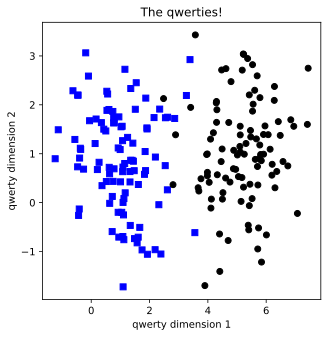

In [3]:
# create data

nPerClust = 100
blur = 1

A = [  1, 1 ]
B = [  5, 1 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

Generates the synthetic data for the classification task and visualizes it. Let's break it down:

----
----

    nPerClust = 100

This sets the number of data points in each of the two clusters to 100.

    blur = 1

This variable controls the spread or variance of the data points within each cluster. A higher value means more spread and overlap between clusters.

    A = [ 1, 1 ]
    B = [ 5, 1 ]

These lines define the mean (center) coordinates for the two clusters, labeled A and B.]

    a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
    b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]

These lines generate the actual data points for each cluster.

They take the mean coordinates (A and B) and add random noise sampled from a standard normal distribution (np.random.randn(nPerClust)) scaled by the blur value.

This creates clusters of data points around the specified means.

    labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

 This creates the true labels for the data. It generates an array of zeros for the first cluster (A) and an array of ones for the second cluster (B), then stacks them vertically to create a single array of labels.

    data_np = np.hstack((a,b)).T
This combines the data points from clusters A and B into a single NumPy array called data_np. np.hstack((a,b)) stacks the two arrays horizontally, and .T transposes the result so that each row represents a data point with two features (dimensions).

    data = torch.tensor(data_np).float() and labels = torch.tensor(labels_np).float()

These lines convert the NumPy arrays data_np and labels_np into PyTorch tensors.

Converting to tensors is necessary because PyTorch models work with tensors. .float() ensures the data type is float, which is common for neural network inputs and labels.

The code then proceeds to plot the generated data using Matplotlib. It plots the data points from cluster A (labels 0) as blue squares ('bs') and data points from cluster B (labels 1) as black circles ('ko'). It also adds a title and axis labels to the plot.

In essence, this cell sets up the problem by creating two separable clusters of data points and their corresponding labels, and then it visualizes these points to show their distribution.



In [4]:
# inspect types
print(type(data_np))
print(np.shape(data_np))
print(' ')

print(type(data))
print(np.shape(data))

<class 'numpy.ndarray'>
(200, 2)
 
<class 'torch.Tensor'>
torch.Size([200, 2])


In [5]:
# build the model
ANNclassify = nn.Sequential(
    nn.Linear(2,1),   # input layer
    nn.ReLU(),        # activation unit
    nn.Linear(1,1),   # output unit
    nn.Sigmoid(),     # final activation unit (here for conceptual reasons; in practice, better to use BCEWithLogitsLoss)
      )

ANNclassify

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
  (3): Sigmoid()
)

In [6]:
# other model features

learningRate = .01

# loss function
lossfun = nn.BCELoss()
# Note: You'll learn in the "Metaparameters" section that it's better to use BCEWithLogitsLoss, but this is OK for now.

# optimizer
optimizer = torch.optim.SGD(ANNclassify.parameters(),lr=learningRate)


# Defines the optimizer and loss function for the neural network.

----
----

    learningRate = .01
This sets the learning rate for the optimizer. The learning rate is a hyperparameter that controls how much the model's weights are adjusted during training.

A smaller learning rate means smaller adjustments, and a larger learning rate means larger adjustments.

    lossfun = nn.BCELoss()
This defines the loss function that will be used to measure the difference between the model's predictions and the true labels. nn.BCELoss() stands for Binary Cross-Entropy Loss, which is commonly used for binary classification problems like this one.

    optimizer = torch.optim.SGD(ANNclassify.parameters(),lr=learningRate)

 This defines the optimizer that will be used to update the model's weights during training. torch.optim.SGD() creates a Stochastic Gradient Descent (SGD) optimizer.

 It takes the model's parameters (ANNclassify.parameters()) and the learning rate (lr=learningRate) as arguments.

 The parameters() method in PyTorch, when called on a module (like your ANNclassify model), is a very important function. It returns an iterator over all the learnable parameters (weights and biases) of the module and its submodules.

In the context of your code, when you use optimizer = torch.optim.SGD(ANNclassify.parameters(),lr=learningRate), you are telling the SGD optimizer which parameters it should update during the training process. The optimizer needs to know which tensors in your model are the ones that need their values adjusted based on the calculated gradients to minimize the loss.

Think of it this way: your ANNclassify model is made up of layers (nn.Linear). Each of these layers has internal weights and biases that the model learns during training. The parameters() method gathers all these learnable weights and biases from across all the layers in your model and presents them to the optimizer.

So, ANNclassify.parameters() provides the optimizer with a list or collection of all the numbers (parameters) within your neural network that need to be tuned during the learning process to improve the model's performance.

What can I help you build?


 The optimizer's job is to minimize the loss function by adjusting the model's parameters based on the gradients calculated during backpropagation.

In [7]:
# train the model
numepochs = 1000
losses = torch.zeros(numepochs)

for epochi in range(numepochs):

  # forward pass
  yHat = ANNclassify(data)

  # compute loss
  loss = lossfun(yHat,labels)
  losses[epochi] = loss

  # backprop
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

# Trains the neural network model. Let's break it down:

-----
----
    numepochs = 1000
This line sets the number of times the entire dataset will be passed forward and backward through the neural network during training.

    losses = torch.zeros(numepochs)
This creates a PyTorch tensor called losses to store the loss value calculated at the end of each training epoch.

It's initialized with zeros and has a size equal to the number of epochs.

    for epochi in range(numepochs):

This starts a loop that will iterate for the specified number of epochs.
yHat = ANNclassify(data): This is the forward pass.

The data (your qwerty data) is fed into the ANNclassify model, and the model outputs its predictions (yHat).

    loss = lossfun(yHat,labels)
This line calculates the loss for the current epoch.

It compares the model's predictions (yHat) with the true labels (labels) using the specified loss function (nn.BCELoss in this case).

    losses[epochi] = loss

The calculated loss for the current epoch is stored in the losses tensor.

    optimizer.zero_grad()
This clears the gradients of all optimized tensors. Gradients are used in the backpropagation process to update the model's weights.

You need to zero them out before calculating new gradients in each epoch.

    loss.backward()
This is the backpropagation step. It computes the gradients of the loss with respect to all the model's parameters.

    optimizer.step():

This updates the model's parameters (weights and biases) based on the calculated gradients and the learning rate defined in the optimizer. This is how the model learns to improve its predictions.

------
#In summary,
this code iteratively feeds the data through the network, calculates the error (loss), and adjusts the network's parameters to minimize that error over many epochs.



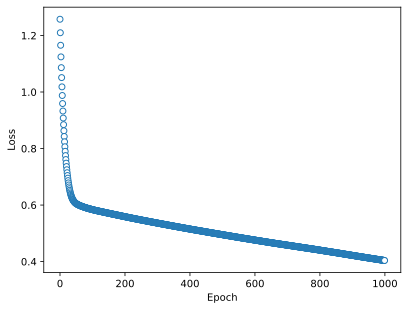

In [8]:
# show the losses

plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Visualizes the training loss over the epochs.

-----------
----------

    plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
This line plots the loss values stored in the losses tensor.

    losses.detach()
Detaches the losses tensor from the computation graph.

You're asking about losses.detach(). In PyTorch, when you perform operations on tensors that have requires_grad=True, PyTorch builds a computation graph.

This graph keeps track of all the operations performed so that it can later compute the gradients during backpropagation (loss.backward()).

The losses tensor is created by calculating the loss from the model's output, which was generated from the input data.

Since the input data (data) was a PyTorch tensor, and the model operations are performed on it, PyTorch is tracking the operations to potentially compute gradients.

However, when you want to plot the loss, you are not interested in calculating gradients with respect to the loss values themselves. You just want the numerical value of the loss to display on the plot.

Calling .detach() on the losses tensor creates a new tensor that has the same values but is disconnected from the computation graph.

This means that no gradients will be calculated for this detached tensor, which is more efficient and appropriate for plotting or other operations where you only need the value and not the gradient information.

Essentially, .detach() gives you a copy of the tensor that you can use for purposes outside of the gradient calculation process.

This is important when plotting because you don't need to track gradients for the plot.

    'o'

Specifies that the data points should be marked with circles.

    markerfacecolor='w'

Sets the face color of the markers to white.

    linewidth=.1

Sets the width of the line connecting the markers to a very thin value.

    plt.xlabel('Epoch')

This sets the label for the x-axis to 'Epoch', representing the training epochs.

    plt.ylabel('Loss')

This sets the label for the y-axis to 'Loss', representing the calculated loss at each epoch.

    plt.show()

This displays the generated plot.

------------
#In summary,
this code creates a plot that shows how the loss of the model decreased (or changed) over the course of the training epochs. This is a common way to visualize the training progress of a neural network.





In [9]:
# compute the predictions

# manually compute losses
# final forward pass
predictions = ANNclassify(data)

predlabels = predictions>.5

# find errors
misclassified = np.where(predlabels != labels)[0]

# total accuracy
totalacc = 100-100*len(misclassified)/(2*nPerClust)

print('Final accuracy: %g%%' %totalacc)


Final accuracy: 89%


# Calculates the model's predictions and then evaluates the accuracy of those predictions by comparing them to the true labels.

-----
Here's a breakdown:

    predictions = ANNclassify(data)
This performs a final forward pass of the entire dataset (data) through the trained neural network model (ANNclassify).

The output, predictions, will be a tensor containing the model's predicted probabilities for each data point belonging to class 1.

    predlabels = predictions>.5
This line converts the predicted probabilities into binary class labels.

Since this is a binary classification problem and the model outputs probabilities between 0 and 1 (due to the Sigmoid activation in the output layer), a threshold of 0.5 is used.

If the predicted probability is greater than 0.5, the data point is assigned to class 1 (True); otherwise, it's assigned to class 0 (False).

    misclassified = np.where(predlabels != labels)[0]

This line identifies the data points that were misclassified.

    predlabels != labels
This creates a boolean array where True indicates a mismatch between the predicted label and the true label, and False indicates a match.

    np.where(...)
This NumPy function returns the indices where the condition is True.

In this case, it returns the indices of the misclassified data points. [0] is used to get the array of indices.

    totalacc = 100-100*len(misclassified)/(2*nPerClust)

This calculates the overall accuracy of the model.

    len(misclassified)

Gets the number of misclassified data points.

    2*nPerClust
This is the total number of data points (since there are nPerClust in each of the two classes).

    len(misclassified) / (2*nPerClust)

Calculates the proportion of misclassified data points.

    100 * ...
Converts the proportion to a percentage.

    100 - ...
Subtracts the percentage of misclassified points from 100 to get the percentage of correctly classified points (accuracy).

    print('Final accuracy: %g%%' %totalacc)
This line prints the calculated final accuracy to the console.

------------
#In essence,
this cell evaluates how well the trained model performs on the dataset by calculating the percentage of data points it classified correctly.

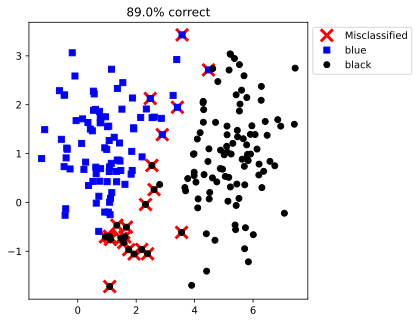

In [10]:
# plot the labeled data
fig = plt.figure(figsize=(5,5))
plt.plot(data[misclassified,0] ,data[misclassified,1],'rx',markersize=12,markeredgewidth=3)
plt.plot(data[np.where(~predlabels)[0],0],data[np.where(~predlabels)[0],1],'bs')
plt.plot(data[np.where(predlabels)[0],0] ,data[np.where(predlabels)[0],1] ,'ko')

plt.legend(['Misclassified','blue','black'],bbox_to_anchor=(1,1))
plt.title(f'{totalacc}% correct')
plt.show()

# Additional explorations

In [11]:
# 1) It is common in DL to train the model for a specified number of epochs. But you can also train until
#    the model reaches a certain accuracy criterion. Re-write the code so that the model continues training
#    until it reaches 90% accuracy.
#    What would happen if the model falls into a local minimum and never reaches 90% accuracy? Yikes! You can
#    force-quit a process in google-colab by clicking on the top-left 'play' button of a code cell.
#
# 2) It is intuitive that the model can reach 100% accuracy if the qwerties are more separable. Modify the
#    qwerty-generating code to get the model to have 100% classification accuracy.
#